<a href="https://colab.research.google.com/github/DariaLaska/ml/blob/main/%D0%B7%D0%B2%D1%83%D0%BA_%D0%BA%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D1%8F_%D0%BC%D1%83%D0%B7%D1%8B%D0%BA%D0%B0%D0%BB%D1%8C%D0%BD%D1%8B%D1%85_%D0%B6%D0%B0%D0%BD%D1%80%D0%BE%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow.keras.utils import to_categorical
from google.colab import files
import os
import librosa
import numpy as np
import time
import matplotlib.pyplot as plt

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input, concatenate
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

Загрузка датасета с сервера

In [ ]:
!wget http://dataset.role.ru/genres.zip

--2026-02-01 12:37:32--  http://dataset.role.ru/genres.zip
Resolving dataset.role.ru (dataset.role.ru)... 176.115.205.154
Connecting to dataset.role.ru (dataset.role.ru)|176.115.205.154|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1226497462 (1.1G) [application/zip]
Saving to: ‘genres.zip’

genres.zip          100%[===================>]   1.14G  12.4MB/s    in 99s     

2026-02-01 12:39:12 (11.8 MB/s) - ‘genres.zip’ saved [1226497462/1226497462]



In [ ]:
!unzip -q genres.zip

In [ ]:
# Функция получения параметров аудио-сигнала
def get_features(x, sr):
  # Параметры окна
  n_fft = 2048       # ~93 мс при sr=22050 - это окно для анализа
  hop_length = 512   # ~23 мс при sr=22050 - на сколько мы сдвигаем окно (шаг между окнами)

  # MFCC - 13 коэффициентов
  mfcc = librosa.feature.mfcc(y=x, sr=sr, n_mfcc=13, n_fft=n_fft, hop_length=hop_length)

  # Delta MFCC - первая производная (скорость изменения)
  delta_mfcc = librosa.feature.delta(mfcc)

  # Delta-Delta MFCC - вторая производная (ускорение изменения)
  delta2_mfcc = librosa.feature.delta(mfcc, order=2)

  # Zero Crossing Rate - частота пересечения нуля
  zcr = np.mean(librosa.feature.zero_crossing_rate(y=x, hop_length=hop_length))

  # Spectral Centroid - "яркость" звука
  spec_cent = np.mean(librosa.feature.spectral_centroid(y=x, sr=sr, n_fft=n_fft, hop_length=hop_length))

  # Spectral Rolloff - спад спектра
  rolloff = np.mean(librosa.feature.spectral_rolloff(y=x, sr=sr, n_fft=n_fft, hop_length=hop_length))


  # Добавляем все параметры в один список
  out = []
  out.append(zcr)        # добавляем zero crossing rate
  out.append(spec_cent)  # добавляем spectral centroid
  out.append(rolloff)    # добавляем spectral rolloff

  # добавляем среднее всех MFCC коэффициентов (13 значений)
  for e in mfcc:
    out.append(np.mean(e))

  # добавляем среднее всех Delta MFCC коэффициентов (13 значений)
  for e in delta_mfcc:
    out.append(np.mean(e))

  # добавляем среднее всех Delta-Delta MFCC коэффициентов (13 значений)
  for e in delta2_mfcc:
    out.append(np.mean(e))

  # Возвращаем 42 значения: 3 + 13 + 13 + 13
  return out

Формирование обучающей выборки

In [ ]:
xTrain = []
yTrain = []

# Получаем список всех жанров (названий поддиректорий)
genres = os.listdir('genres')
class_num = len(genres)


# Проходим по всем жанрам
for i in range(class_num):
  # Запоминаем время старта формирования выборки
  start_time = time.time()

  # Берём название текущего жанра
  g = genres[i]

  # Проходим по файлам папки, соответствующей текущему жанру
  for filename in os.listdir(f'./genres/{g}'):
    # Получаем полное имя файла песни
    songname = f'./genres/{g}/{filename}'

    # Загружаем аудиосигнал
    x, sr = librosa.load(songname, mono=True, offset=7.5, duration=15, sr=22050)
    # x - массив семплов
    # sr - частота дискретизации
    # offset - сдвиг относительно начала. Берём из середины (файлы по 30 сек)
    # duration - продолжительность отрывка. Берём по 15 секунд
    # sr=22050 - приводим к частоте 22050 Гц

    # Параметризуем аудио-сигнал
    out = get_features(x, sr)

    xTrain.append(out)
    yTrain.append(to_categorical(i, class_num))

  # Выводим информацию о готовности обработки датасета
  print(g, ":", round(time.time() - start_time), "c")


# Переводим данные в numpy массивы
xTrain = np.array(xTrain)
yTrain = np.array(yTrain)

country : 41 c
jazz : 11 c
disco : 17 c
classical : 15 c
pop : 14 c
reggae : 12 c
blues : 10 c
rock : 17 c
metal : 13 c
hiphop : 10 c


In [ ]:
# Проверяем yTrain
y_train_class = np.argmax(yTrain, axis=1)
print(y_train_class)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 

In [ ]:
# Выводим размерности обучающей выборки
print("xTrain:", xTrain.shape)
print("yTrain:", yTrain.shape)

xTrain: (1000, 42)
yTrain: (1000, 10)


In [ ]:
# Разделяем выборку на обучающую и валидационную. На валидационную отдаем 15%
xTrainS, xVal, yTrainS, yVal = train_test_split(xTrain, yTrain, test_size=0.15)

In [ ]:
# Нормирование данных

# Создаём экземпляр класса StandardScaler для нормирования данных
scaler = StandardScaler()
scaler.fit(np.concatenate((xTrainS, xVal)))

# Нормируем X_train и X_val
xTrainS = scaler.transform(xTrainS)
xVal = scaler.transform(xVal)

ДО НОРМАЛИЗАЦИИ:
Zero Crossing Rate:   min=0.020531,  max=0.322396
Spectral Centroid:    min=539.81,  max=5414.04
Spectral Rolloff:     min=754.11,  max=9275.61
MFCC[0]:              min=-616.54,  max=104.91

Первый образец (первые 6 признаков):
[ 4.77533016e-02  9.90069194e+02  1.80395576e+03 -2.21614471e+02
  1.78660431e+02  4.48731804e+00]

ПОСЛЕ НОРМАЛИЗАЦИИ:
Zero Crossing Rate:   min=-1.935091,  max=5.111045,  mean=0.009615
Spectral Centroid:    min=-2.296462,  max=4.432720,  mean=-0.005668
Spectral Rolloff:     min=-2.410591,  max=2.962101,  mean=-0.011900
MFCC[0]:              min=-4.608525,  max=2.427865,  mean=-0.003361

Первый образец после нормализации (первые 6 признаков):
[ 0.48918079  1.3118867   1.36060063  0.33542152 -1.16450792  1.02773468]



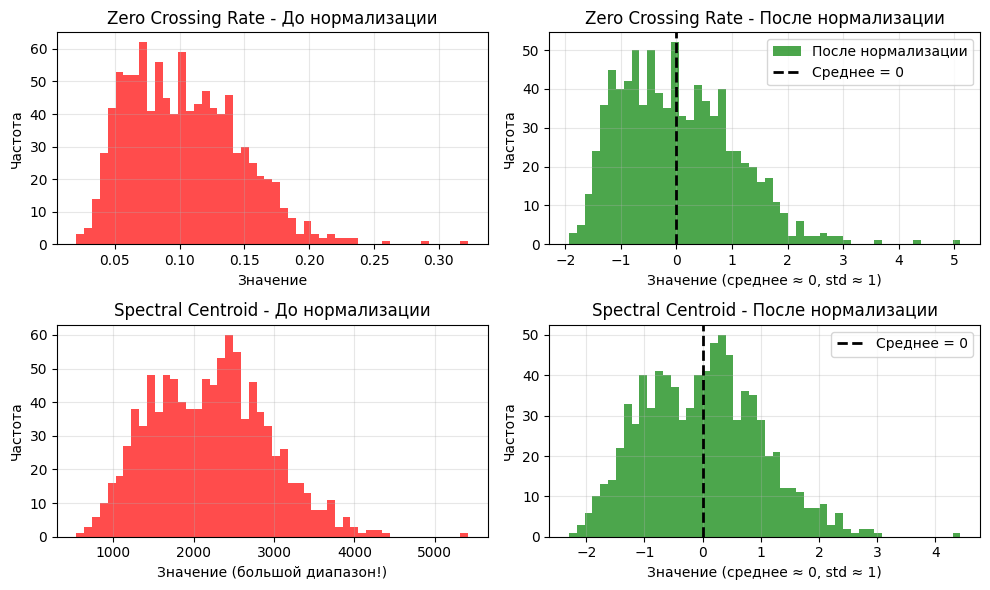

ВЫВОДЫ:
До нормализации: признаки в разных масштабах (0.1 vs 3000 vs 7000)
После нормализации: все признаки центрированы около 0 со std ≈ 1
Нейросеть будет обучаться ГОРАЗДО быстрее и точнее


In [ ]:
# Визуализация эффекта нормализации

# Создаём копию данных до нормализации
xTrain_before = xTrain.copy()

# Выводим статистику ДО нормализации
print("="*70)
print("ДО НОРМАЛИЗАЦИИ:")
print("="*70)
print(f"Zero Crossing Rate:   min={xTrain_before[:, 0].min():.6f},  max={xTrain_before[:, 0].max():.6f}")
print(f"Spectral Centroid:    min={xTrain_before[:, 1].min():.2f},  max={xTrain_before[:, 1].max():.2f}")
print(f"Spectral Rolloff:     min={xTrain_before[:, 2].min():.2f},  max={xTrain_before[:, 2].max():.2f}")
print(f"MFCC[0]:              min={xTrain_before[:, 3].min():.2f},  max={xTrain_before[:, 3].max():.2f}")
print()

# Выводим первый образец
print("Первый образец (первые 6 признаков):")
print(xTrain_before[0][:6])
print()

# Выводим статистику ПОСЛЕ нормализации (используем уже нормализованные данные)
print("="*70)
print("ПОСЛЕ НОРМАЛИЗАЦИИ:")
print("="*70)
print(f"Zero Crossing Rate:   min={xTrainS[:, 0].min():.6f},  max={xTrainS[:, 0].max():.6f},  mean={xTrainS[:, 0].mean():.6f}")
print(f"Spectral Centroid:    min={xTrainS[:, 1].min():.6f},  max={xTrainS[:, 1].max():.6f},  mean={xTrainS[:, 1].mean():.6f}")
print(f"Spectral Rolloff:     min={xTrainS[:, 2].min():.6f},  max={xTrainS[:, 2].max():.6f},  mean={xTrainS[:, 2].mean():.6f}")
print(f"MFCC[0]:              min={xTrainS[:, 3].min():.6f},  max={xTrainS[:, 3].max():.6f},  mean={xTrainS[:, 3].mean():.6f}")
print()

# Выводим первый образец после нормализации
print("Первый образец после нормализации (первые 6 признаков):")
print(xTrainS[0][:6])
print()

# Визуализация распределений
fig, axes = plt.subplots(2, 2, figsize=(10, 6))

# График 1: Zero Crossing Rate
axes[0, 0].hist(xTrain_before[:, 0], bins=50, alpha=0.7, color='red', label='До нормализации')
axes[0, 0].set_title('Zero Crossing Rate - До нормализации')
axes[0, 0].set_xlabel('Значение')
axes[0, 0].set_ylabel('Частота')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(xTrainS[:, 0], bins=50, alpha=0.7, color='green', label='После нормализации')
axes[0, 1].set_title('Zero Crossing Rate - После нормализации')
axes[0, 1].set_xlabel('Значение (среднее ≈ 0, std ≈ 1)')
axes[0, 1].set_ylabel('Частота')
axes[0, 1].axvline(x=0, color='black', linestyle='--', linewidth=2, label='Среднее = 0')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# График 2: Spectral Centroid
axes[1, 0].hist(xTrain_before[:, 1], bins=50, alpha=0.7, color='red')
axes[1, 0].set_title('Spectral Centroid - До нормализации')
axes[1, 0].set_xlabel('Значение (большой диапазон!)')
axes[1, 0].set_ylabel('Частота')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(xTrainS[:, 1], bins=50, alpha=0.7, color='green')
axes[1, 1].set_title('Spectral Centroid - После нормализации')
axes[1, 1].set_xlabel('Значение (среднее ≈ 0, std ≈ 1)')
axes[1, 1].set_ylabel('Частота')
axes[1, 1].axvline(x=0, color='black', linestyle='--', linewidth=2, label='Среднее = 0')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("ВЫВОДЫ:")
print("До нормализации: признаки в разных масштабах (0.1 vs 3000 vs 7000)")
print("После нормализации: все признаки центрированы около 0 со std ≈ 1")
print("Нейросеть будет обучаться ГОРАЗДО быстрее и точнее")

In [ ]:
# Выводим размерности обучающей и валидационной выборки
print(xTrainS.shape)
print(yTrainS.shape)
print(xVal.shape)
print(yVal.shape)

(850, 42)
(850, 10)
(150, 42)
(150, 10)


Модель 1: Простая нейросеть для классификации

In [ ]:
# Количество признаков и классов
num_features = xTrainS.shape[1]
num_classes = class_num

print("Количество признаков:", num_features)
print("Количество жанров:", num_classes)

# Создаём простую модель (Модель 1)
model1 = Sequential()

# Входной слой + первый скрытый слой
model1.add(Dense(512, activation='relu', input_shape=(num_features,)))
model1.add(BatchNormalization())
model1.add(Dropout(0.3))

# Второй скрытый слой
model1.add(Dense(256, activation='relu'))
model1.add(BatchNormalization())
model1.add(Dropout(0.3))

# Третий скрытый слой
model1.add(Dense(128, activation='relu'))
model1.add(BatchNormalization())
model1.add(Dropout(0.3))

# Выходной слой
model1.add(Dense(num_classes, activation='softmax'))

# Компилируем модель
model1.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Обучаем модель
history1 = model1.fit(
    xTrainS, yTrainS,
    validation_data=(xVal, yVal),
    epochs=100,
    batch_size=32
)

Количество признаков: 42
Количество жанров: 10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 168ms/step - accuracy: 0.0880 - loss: 3.2935 - val_accuracy: 0.1267 - val_loss: 2.2718
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1425 - loss: 2.8893 - val_accuracy: 0.1600 - val_loss: 2.2300
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1942 - loss: 2.6795 - val_accuracy: 0.2200 - val_loss: 2.1799
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1875 - loss: 2.6269 - val_accuracy: 0.2600 - val_loss: 2.1264
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2440 - loss: 2.4240 - val_accuracy: 0.3000 - val_loss: 2.0684
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2652 - loss: 2.2886 - val_accuracy: 0.3067 - val_loss: 2.0076
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3202 - loss: 2.1559 - val_accuracy: 0.3200 - val_loss: 1.9514
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2703 - loss: 2.1749 - val_accuracy: 0.3467 

Визуализация результатов Модели 1

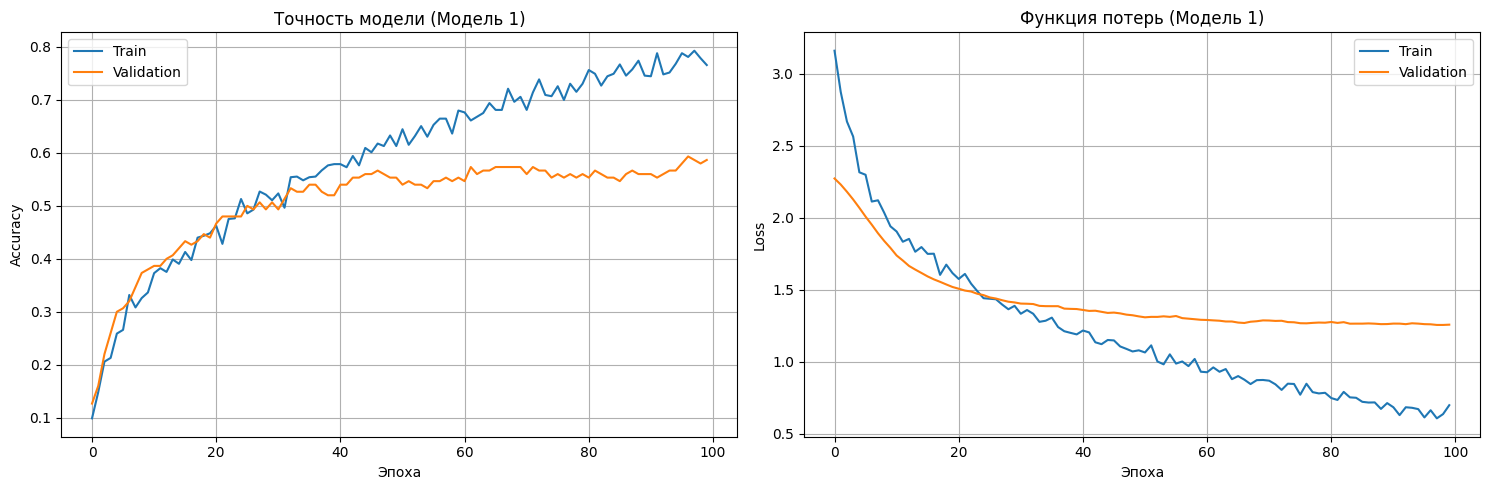

In [ ]:
# Строим графики
plt.figure(figsize=(15, 5))

# График точности
plt.subplot(1, 2, 1)
plt.plot(history1.history['accuracy'], label='Train')
plt.plot(history1.history['val_accuracy'], label='Validation')
plt.title('Точность модели (Модель 1)')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# График loss
plt.subplot(1, 2, 2)
plt.plot(history1.history['loss'], label='Train')
plt.plot(history1.history['val_loss'], label='Validation')
plt.title('Функция потерь (Модель 1)')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Оценка качества Модели 1

In [ ]:
# Оцениваем модель на валидационной выборке
val_loss, val_accuracy = model1.evaluate(xVal, yVal)

print("\nМодель 1 - Валидационная точность:", val_accuracy)
print("Модель 1 - Валидационный loss:", val_loss)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5519 - loss: 1.3197

Модель 1 - Валидационная точность: 0.5866666436195374
Модель 1 - Валидационный loss: 1.2578705549240112


Матрица ошибок для Модели 1

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step


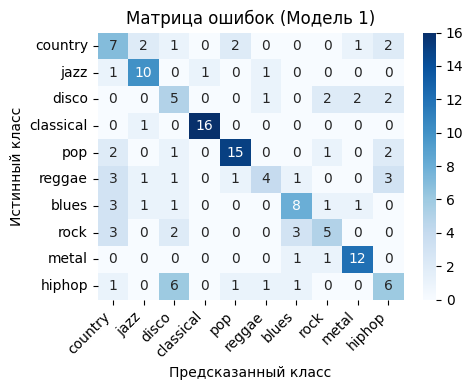

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Получаем предсказания
y_pred = model1.predict(xVal)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(yVal, axis=1)

# Строим матрицу ошибок
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=genres, yticklabels=genres)
plt.title('Матрица ошибок (Модель 1)')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Модель 2: Продвинутая нейросеть с несколькими ветками

Создадим более сложную модель с функциональным API:
- Ветка 1: обрабатывает базовые спектральные признаки (ZCR, Centroid, Rolloff)
- Ветка 2: обрабатывает MFCC признаки
- Ветка 3: обрабатывает Delta MFCC (скорость изменения)
- Ветка 4: обрабатывает Delta-Delta MFCC (ускорение изменения)

Каждая ветка специализируется на своём типе признаков, затем они объединяются

In [ ]:
# Создаём продвинутую модель с несколькими ветками (Модель 2)
# Каждая ветка обрабатывает свою группу признаков

from tensorflow.keras.layers import Lambda
import tensorflow as tf

# Входной слой
input_layer = Input(shape=(num_features,))

# Разделяем признаки на 4 группы:
# Индексы 0-2: Zero Crossing Rate, Spectral Centroid, Spectral Rolloff (3 признака)
# Индексы 3-15: MFCC (13 признаков)
# Индексы 16-28: Delta MFCC (13 признаков)
# Индексы 29-41: Delta-Delta MFCC (13 признаков)

# Извлекаем группы признаков
features_basic = Lambda(lambda x: x[:, 0:3])(input_layer)     # ZCR, Centroid, Rolloff
#features_mfcc = Lambda(lambda x: x[:, 3:16])(input_layer)     # MFCC
#mfcc0 отбрасываем
mfcc_1_4 = Lambda(lambda x: x[:, 4:8])(input_layer)
mfcc_5_8 = Lambda(lambda x: x[:, 8:12])(input_layer)
mfcc_9_12 = Lambda(lambda x: x[:, 12:16])(input_layer)

features_delta = Lambda(lambda x: x[:, 16:29])(input_layer)   # Delta MFCC
features_delta2 = Lambda(lambda x: x[:, 29:42])(input_layer)  # Delta-Delta MFCC

# Ветка 1: обрабатывает базовые спектральные признаки (3 признака)
branch1 = Dense(64, activation='relu')(features_basic)
branch1 = BatchNormalization()(branch1)
branch1 = Dropout(0.3)(branch1)
branch1 = Dense(32, activation='relu')(branch1)
branch1 = BatchNormalization()(branch1)

# Ветка 2: обрабатывает MFCC_1-4 (13 признаков)
branch2 = Dense(32, activation='relu')(mfcc_1_4)
branch2 = BatchNormalization()(branch2)
branch2 = Dropout(0.3)(branch2)
branch2 = Dense(16, activation='relu')(branch2)
branch2 = BatchNormalization()(branch2)
branch2 = Dropout(0.3)(branch2)


# Ветка 2: обрабатывает MFCC_5-8 (13 признаков)
branch3 = Dense(32, activation='relu')(mfcc_5_8)
branch3 = BatchNormalization()(branch3)
branch3 = Dropout(0.3)(branch3)
branch3 = Dense(16, activation='relu')(branch3)
branch3 = BatchNormalization()(branch3)
branch3 = Dropout(0.3)(branch3)


# Ветка 2: обрабатывает MFCC_9-12 (13 признаков)
branch4 = Dense(32, activation='relu')(mfcc_9_12)
branch4 = BatchNormalization()(branch4)
branch4 = Dropout(0.3)(branch4)
branch4 = Dense(16, activation='relu')(branch4)
branch4 = BatchNormalization()(branch4)
branch4 = Dropout(0.3)(branch4)


# Ветка 3: обрабатывает Delta MFCC (13 признаков)
branch5 = Dense(64, activation='relu')(features_delta)
branch5 = BatchNormalization()(branch5)
branch5 = Dropout(0.3)(branch5)
branch5 = Dense(32, activation='relu')(branch5)
branch5 = BatchNormalization()(branch5)
branch5 = Dropout(0.3)(branch5)

# Ветка 4: обрабатывает Delta-Delta MFCC (13 признаков)
branch6 = Dense(64, activation='relu')(features_delta2)
branch6 = BatchNormalization()(branch6)
branch6 = Dropout(0.3)(branch6)
branch6 = Dense(32, activation='relu')(branch6)
branch6 = BatchNormalization()(branch6)
branch6 = Dropout(0.3)(branch6)

# Объединяем все ветки
# branch1: 32 нейрона, branch2-4: 16*3, branch5: 64, branch6: 64 = 224-18-64 нейрона
merged = concatenate([branch1, branch2, branch3, branch4, branch5, branch6])

# Полносвязные слои после объединения
x = Dense(256, activation='relu')(merged)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

# Выходной слой
output = Dense(num_classes, activation='softmax')(x)

# Создаём модель
model2 = Model(inputs=input_layer, outputs=output)

# Компилируем модель
model2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Выводим архитектуру
model2.summary()

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 42)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_17 (Lambda)  │ (None, 4)         │          0 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_18 (Lambda)  │ (None, 4)         │          0 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_19 (Lambda)  │ (None, 4)         │          0 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_20 (Lambda)  │ (None, 13)        │          0 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_21 (Lambda)  │ (None, 13)        │          0 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_16 (Lambda)  │ (None, 3)         │          0 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_47 (Dense)    │ (None, 32)        │        160 │ lambda_17[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_49 (Dense)    │ (None, 32)        │        160 │ lambda_18[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_51 (Dense)    │ (None, 32)        │        160 │ lambda_19[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_53 (Dense)    │ (None, 64)        │        896 │ lambda_20[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_55 (Dense)    │ (None, 64)        │        896 │ lambda_21[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_45 (Dense)    │ (None, 64)        │        256 │ lambda_16[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_47[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_49[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_51[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_53[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_55[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_45[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_39          │ (None, 32)        │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_41          │ (None, 32)        │          0 │ batch_normalizat

 Total params: 84,922 (331.73 KB)

 Trainable params: 83,290 (325.35 KB)

 Non-trainable params: 1,632 (6.38 KB)

In [ ]:
print(224-18-64)

142


In [ ]:
# Обучаем продвинутую модель
history2 = model2.fit(
    xTrainS, yTrainS,
    validation_data=(xVal, yVal),
    epochs=100,
    batch_size=32
)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 33s 512ms/step - accuracy: 0.1110 - loss: 3.1246 - val_accuracy: 0.2667 - val_loss: 2.1970
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2757 - loss: 2.3809 - val_accuracy: 0.2733 - val_loss: 2.1142
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3208 - loss: 2.1960 - val_accuracy: 0.2600 - val_loss: 2.0573
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3156 - loss: 2.1026 - val_accuracy: 0.2600 - val_loss: 2.0273
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3513 - loss: 1.9794 - val_accuracy: 0.2333 - val_loss: 1.9697
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3530 - loss: 1.8821 - val_accuracy: 0.2467 - val_loss: 1.9083
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4024 - loss: 1.8056 - val_accuracy: 0.2733 - val_loss: 1.8519
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3940 - loss: 1.7877 - val_accuracy: 0.3200 

Визуализация результатов Модели 2

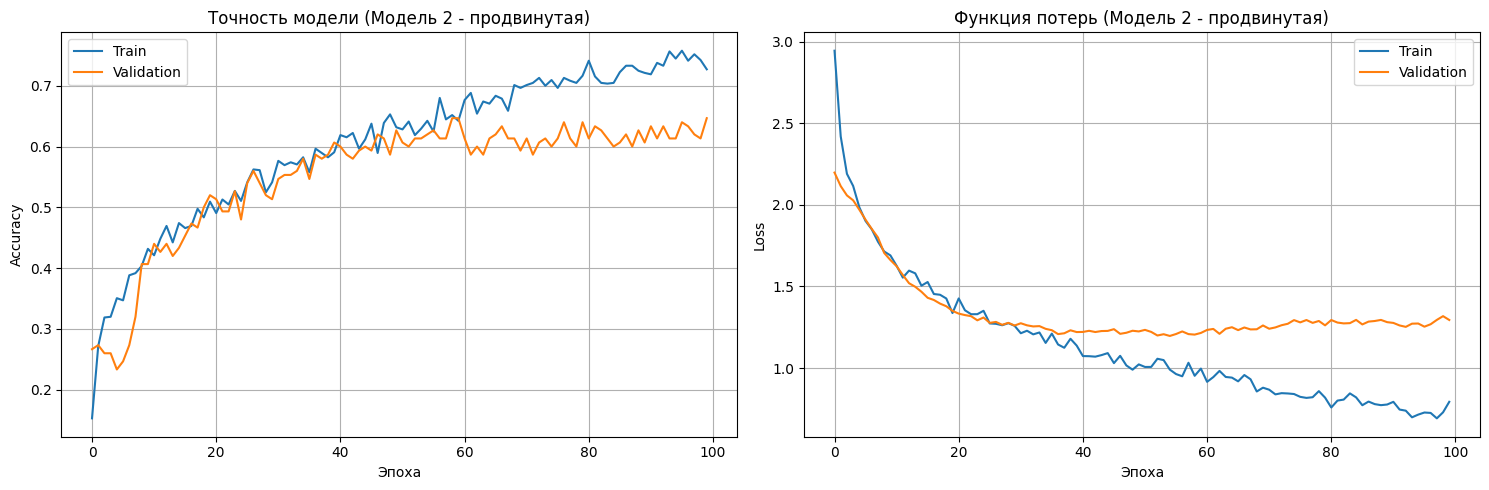

In [ ]:
# Строим графики для Модели 2
plt.figure(figsize=(15, 5))

# График точности
plt.subplot(1, 2, 1)
plt.plot(history2.history['accuracy'], label='Train')
plt.plot(history2.history['val_accuracy'], label='Validation')
plt.title('Точность модели (Модель 2 - продвинутая)')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# График loss
plt.subplot(1, 2, 2)
plt.plot(history2.history['loss'], label='Train')
plt.plot(history2.history['val_loss'], label='Validation')
plt.title('Функция потерь (Модель 2 - продвинутая)')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Оценка качества Модели 2

In [ ]:
# Оцениваем продвинутую модель
val_loss2, val_accuracy2 = model2.evaluate(xVal, yVal)

print("\nМодель 2 - Валидационная точность:", val_accuracy2)
print("Модель 2 - Валидационный loss:", val_loss2)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6353 - loss: 1.3045 

Модель 2 - Валидационная точность: 0.6466666460037231
Модель 2 - Валидационный loss: 1.294232964515686


Матрица ошибок для Модели 2

1/5 ━━━━━━━━━━━━━━━━━━━━ 3s 930ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 233ms/step


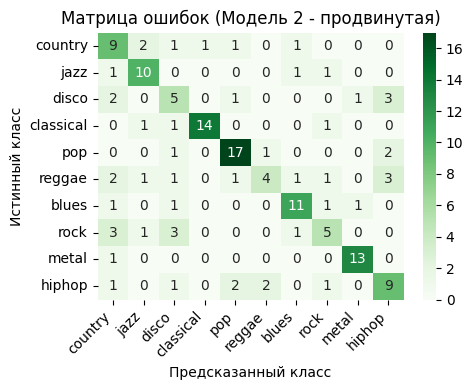

In [ ]:
# Получаем предсказания для Модели 2
y_pred2 = model2.predict(xVal)
y_pred2_classes = np.argmax(y_pred2, axis=1)

# Строим матрицу ошибок
cm2 = confusion_matrix(y_true_classes, y_pred2_classes)

plt.figure(figsize=(5, 4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens',
            xticklabels=genres, yticklabels=genres)
plt.title('Матрица ошибок (Модель 2 - продвинутая)')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Сравнение двух моделей

In [ ]:
# Сравнение моделей
print("============================================================")
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("============================================================")
print(f"Модель 1 (простая):      Точность = {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
print(f"Модель 2 (продвинутая):  Точность = {val_accuracy2:.4f} ({val_accuracy2*100:.2f}%)")
print("============================================================")

if val_accuracy2 > val_accuracy:
    improvement = (val_accuracy2 - val_accuracy) * 100
    print(f"Модель 2 лучше на {improvement:.2f}%")
elif val_accuracy > val_accuracy2:
    improvement = (val_accuracy - val_accuracy2) * 100
    print(f"Модель 1 лучше на {improvement:.2f}%")
else:
    print("Модели показывают одинаковую точность")

СРАВНЕНИЕ МОДЕЛЕЙ
Модель 1 (простая):      Точность = 0.5867 (58.67%)
Модель 2 (продвинутая):  Точность = 0.6467 (64.67%)
Модель 2 лучше на 6.00%


Распознавание жанра загруженного файла

Загрузите свой музыкальный файл и узнайте его жанр!

In [ ]:
# Загружаем файл от пользователя
uploaded = files.upload()

KeyboardInterrupt: 

In [ ]:
# Выбираем песню для распознавания
# Берём имя загруженного файла
songname = list(uploaded.keys())[0]

# Загружаем файл для параметризации
y, sr = librosa.load(songname, mono=True, offset=10, duration=15)
# Параметризуем сигнал
out = get_features(y, sr)
# Добавляем размерность, т.к. на вход нейронки подается массив из параметров n-числа композиций. В нашем случае - n = 1
out = np.array(out).reshape(1, len(out))
# Берем ранее подготовленный Scaler и нормализуем
out = scaler.transform(out)
# Делаем predict на Модели 2 (продвинутой)
prediction = model2.predict(out)
predict_class = np.argmax(prediction[0])

# Вывод нейронки
print("Выход сети:")
print(prediction[0])
print()
for i in range(10):
  print(i,"->","{:.40f}".format(prediction[0][i]))
print()
print("Номер распознанного жанра: ", predict_class)
print("Распознанный жанр: ", genres[predict_class])

# Метод усреднения

Мы берем много кусков из песни, определяем их жанр, и выбираем тот жанр, кусков которого оказалось большое

In [ ]:
def predict_full_song(filename, model, scaler, n_segments=10):
  """
  Классификация всей песни через усреднение нескольких отрезков

  filename - путь к файлу
  model - обученная модель
  scaler - нормализатор
  n_segments - количество отрезков для анализа

  Возвращает: predicted_class, avg_prediction, segment_predictions
  """
  # Загружаем полную песню
  y_full, sr = librosa.load(filename, mono=True, sr=22050)
  duration = len(y_full) / sr  # длительность в секундах

  # Длительность одного отрезка
  segment_duration = 15  # секунд

  # Вычисляем, сколько отрезков можем взять
  max_segments = int(duration / segment_duration)
  n_segments = min(n_segments, max_segments)

  # Равномерно распределяем отрезки по всей песне
  predictions = []
  segment_info = []  # Информация о каждом сегменте

  for i in range(n_segments):
    offset = i * (duration - segment_duration) / (n_segments - 1) if n_segments > 1 else 0

    # Загружаем отрезок
    y, sr = librosa.load(filename, mono=True, offset=offset, duration=segment_duration, sr=22050)

    # Извлекаем признаки
    features = get_features(y, sr)
    features = np.array(features).reshape(1, -1)
    features = scaler.transform(features)

    # Предсказываем
    pred = model.predict(features, verbose=0)
    predictions.append(pred[0])

    # Сохраняем информацию о сегменте
    predicted_class = np.argmax(pred[0])
    confidence = pred[0][predicted_class]
    segment_info.append({
      'segment_num': i + 1,
      'time_start': offset,
      'time_end': offset + segment_duration,
      'predicted_class': predicted_class,
      'confidence': confidence,
      'probabilities': pred[0]
    })

  # Усредняем все предсказания
  avg_prediction = np.mean(predictions, axis=0)
  predicted_class = np.argmax(avg_prediction)

  return predicted_class, avg_prediction, segment_info

In [ ]:
songname = list(uploaded.keys())[0]

# Классифицируем всю песню (анализируем несколько отрезков)
predicted_class, avg_prediction, segment_info = predict_full_song(songname, model2, scaler, n_segments=15)

# Выводим информацию по каждому отрезку
print("="*80)
print("АНАЛИЗ ОТРЕЗКОВ ПЕСНИ:")
print("="*80)
for seg in segment_info:
  time_str = f"{int(seg['time_start']//60):02d}:{int(seg['time_start']%60):02d} - {int(seg['time_end']//60):02d}:{int(seg['time_end']%60):02d}"
  print(f"Отрезок {seg['segment_num']:2d} ({time_str}): {genres[seg['predicted_class']]:12s} (уверенность: {seg['confidence']:.2%})")

print()
print("="*80)
print("УСРЕДНЁННЫЙ ВЫХОД СЕТИ (по всем отрезкам):")
print("="*80)
print(avg_prediction)
print()
for i in range(10):
  print(i,"->","{:.40f}".format(avg_prediction[i]))
print()
print("="*80)
print("ИТОГОВЫЙ РЕЗУЛЬТАТ:")
print("="*80)
print("Номер распознанного жанра: ", predicted_class)
print("Распознанный жанр: ", genres[predicted_class])
print("="*80)

